In [1]:
import datetime
from dateutil.relativedelta import relativedelta
import time
import json
import math
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

from castlib.cast import Cast
from castlib.reporter import Reporter
from castlib.prop import Prop
from castlib.event import Event

import pandas as pd
import yfinance as yf

# Shared Cost Calculation

In [3]:
d = datetime.date

shared_monthly_events = [
    Event(name="Rent", amount=-3900, date=d(2020, 2, 1)),
    Event(name="Utils", amount=-300, date=d(2020, 2, 15)),
    Event(name="Progressive", amount=-290, date=d(2020, 2, 18)),
    Event(name="Xfinity", amount=-89, date=d(2020, 1, 1)),
    Event(name="Sprint", amount=-300, date=d(2020, 6, 1)),
    Event(name="Food/Cons.", amount=-150, date=d(2020, 2, 2)),
]

healthcare = 150
total_split_cost = healthcare + 0

# halve each shared event and supply a total for rebecca
for event in shared_monthly_events:
    event.amount /= 2
    total_split_cost += abs(event.amount)

print(f"Total monthly balance for Rebecca: ${total_split_cost}")

Total monthly balance for Rebecca: $2664.5


# Stock Comp Calculation

In [14]:
# config
total_shares = 680
tax_rate = 0.4

symbol = 'NVDA'
data = yf.Ticker(symbol)
df = data.history(period="1d")

#see your data
latest_price = df["Close"][0]
shares_this_year = 680/4

grant_value = shares_this_year * latest_price

stock_grant = Event(
    name="NVIDIA Stock Grant", 
    amount=grant_value*(1-tax_rate), 
    date=d(2021, 9, 1)
).yearly

print(f"RSU grant is currently worth: ${math.floor(grant_value)}")
print(f"NVDA is currently worth ${latest_price}")

RSU grant is currently worth: $88823
NVDA is currently worth $522.49


First day over $1mm: 1970-01-01


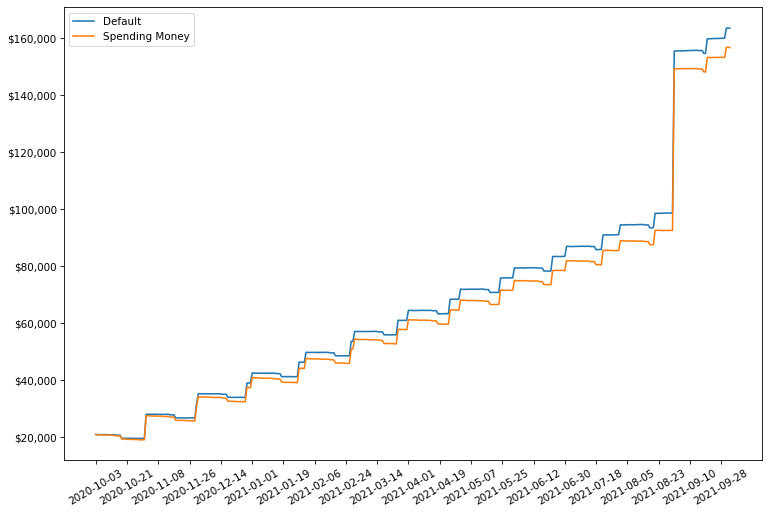

In [15]:
# config
monthly_spending_money = 500
monthly_401k = 300 * 2


c = (Cast(balance=21000, start=d.today())
    .end_after(years=1)
    .report_with(Reporter)
    .set_min_cash(5000)
    .at_apr(8)
     
    .add_event(Event(name="NVIDIA Post-Tax Salary", amount=5055, date=d(2020, 11, 1)).semi_monthly)
    .add_event(Event(name="Carmax", amount=-910, date=d(2020, 2, 18)).monthly)
    .add_event(Event(name="Signing Bonus", amount=17000, date=d(2020, 9, 30)))
    .add_event(stock_grant)
    .add_event(Event(name="Savings", amount=monthly_401k, date=d(2020, 1, 1)).monthly)
     
    .add_event(Event(name="Gas", amount=-60, date=d(2020, 2, 2)).weekly)
)

# add all monthly events in shared set
for event in shared_monthly_events:
    c.add_event(event.monthly)

spending_money = Prop(Event(name="", amount=-(monthly_spending_money/4), date=d(2020, 1, 1)).weekly, "Spending Money")
    
c.report.running_balance(props=[spending_money]);
print(f"First day over $1mm: {str(c.first_day_over(1e6))}")

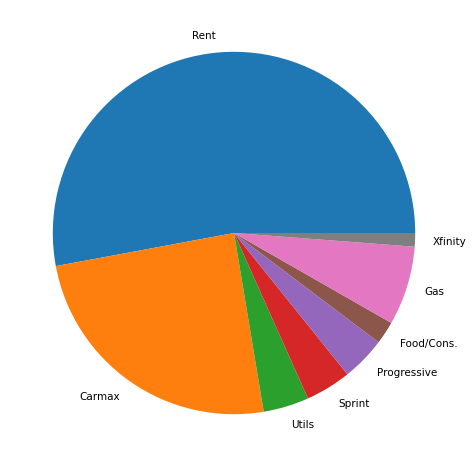

In [8]:
c.trim()
c.report.tx_pie()